In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from scipy.integrate import quad
from scipy.special import spherical_jn

In [3]:
import sys
sys.path.append("../src/")
from interpolation import RDP_subsample
from polybessel import PolyBessel

/Users/alexlague/Documents/act/sfb/repo/polybessel/notebooks/../src/polybessel.py:79: SyntaxWarning: invalid escape sequence '\i'
  """
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


We wish to evaluate integrals of the form

$$\int_{x_a}^{x_b} f(x) j_\ell(\omega x) dx, $$

for an example function

$$f(x) = 4\pi x^2 \exp(-x^2/4). $$

In [35]:
# 1. A simple, smooth (non-oscillatory) test function.
def f(x):
    return np.exp(-x**2 / 4.0)

# 2. Sample function on grid and specify wanted \omega and \ell
xs = np.linspace(0.1, 8.0, 1024)
fx = 4 * np.pi * xs**2 * f(xs)

freqs = np.linspace(0.2, 3.0, 256)
ls = [2, 5, 21]

In [36]:
# 3. Initialize PolyBessel instance

PB = PolyBessel(xs, ls, freqs)

In [37]:
# 4. Compute the integral of f(x) against sph. Bessel func.

result = PB.integrate_single_bessel(fx)

In [38]:
print("l    k          our result       scipy quad       rel diff     abs diff")
for li, l in enumerate(ls):
    for ki in [0, 25, 49]:
        k = freqs[ki]
        true_val = quad(lambda xx: 4*np.pi*xx**2*f(xx)*spherical_jn(l, k*xx),
                             xs.min(), xs.max(), limit=200)[0]
        approx = result[li, ki]
        print(f"{l:<3}  {k:6.3f}  {approx: .10f}  {true_val: .10f}  {abs(approx/true_val-1):.2e}   {abs(approx-true_val):.2e}")

l    k          our result       scipy quad       rel diff     abs diff
2     0.200   0.6926827542   0.6926916270  1.28e-05   8.87e-06
2     0.475   3.4199717155   3.4199718633  4.32e-08   1.48e-07
2     0.738   6.6231567270   6.6231575451  1.24e-07   8.18e-07
5     0.200   0.0002898568   0.0002898544  8.16e-06   2.37e-09
5     0.475   0.0194591555   0.0194590069  7.63e-06   1.49e-07
5     0.738   0.1460871914   0.1460861499  7.13e-06   1.04e-06
21    0.200   0.0000000000   0.0000000000  4.29e-05   5.74e-31
21    0.475   0.0000000000   0.0000000000  4.26e-05   3.95e-23
21    0.738   0.0000000000   0.0000000000  4.21e-05   3.56e-19


In [39]:
%timeit PB.integrate_single_bessel(fx)

799 μs ± 12.1 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


Pretty fast, but could be better at the expense of (some) accuracy!

We use the RDP method to subsample the function $f(x)$ at points where the linear interpolation struggles the most. On straight segments, we keep fewer points.

In [40]:
from interpolation import RDP_subsample

In [54]:
subsamp = RDP_subsample(xs, fx, abs_tol=1e-3, rel_tol=1e-4)

Fraction of points kept:  19.0 %


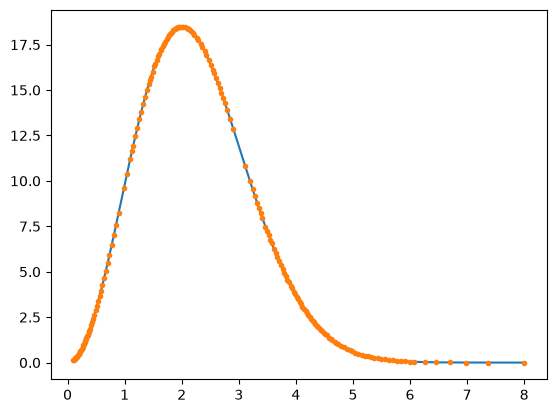

In [61]:
plt.plot(xs, fx)
plt.plot(xs[subsamp], fx[subsamp], '.')
print("Fraction of points kept: ", 100 * round(len(xs[subsamp])/len(xs), 2), "%")

In [62]:
# We create a new instance, since the x-grid has changed

PB_sub = PolyBessel(xs[subsamp], ls, freqs)

In [63]:
# Recompute

result_sub = PB_sub.integrate_single_bessel(fx[subsamp])

In [64]:
print("l    k          our result       scipy quad       rel diff     abs diff")
for li, l in enumerate(ls):
    for ki in [0, 25, 49]:
        k = freqs[ki]
        true_val = quad(lambda xx: 4*np.pi*xx**2*f(xx)*spherical_jn(l, k*xx),
                             xs.min(), xs.max(), limit=200)[0]
        approx = result_sub[li, ki]
        print(f"{l:<3}  {k:6.3f}  {approx: .10f}  {true_val: .10f}  {abs(approx/true_val-1):.2e}   {abs(approx-true_val):.2e}")

l    k          our result       scipy quad       rel diff     abs diff
2     0.200   0.6927834916   0.6926916270  1.33e-04   9.19e-05
2     0.475   3.4202818563   3.4199718633  9.06e-05   3.10e-04
2     0.738   6.6233293265   6.6231575451  2.59e-05   1.72e-04
5     0.200   0.0002901811   0.0002898544  1.13e-03   3.27e-07
5     0.475   0.0194769721   0.0194590069  9.23e-04   1.80e-05
5     0.738   0.1461798329   0.1460861499  6.41e-04   9.37e-05
21    0.200   0.0000000000   0.0000000000  1.25e-01   1.68e-27
21    0.475   0.0000000000   0.0000000000  1.22e-01   1.13e-19
21    0.738   0.0000000000   0.0000000000  1.17e-01   9.91e-16


Not as accurate, but not bad. Let's see how fast this performs now. We should get a new execution time comparable to the percentage of points kept.

In [59]:
%timeit PB_sub.integrate_single_bessel(fx[subsamp])

154 μs ± 3.04 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
